# Week 4: Feature Engineering and Stability Analysis

## Objective

This notebook explores feature engineering, scaling experiments, and stability analysis for tree-based machine learning models using the UCI Concrete dataset.

Main goals:

- Create engineered features
- Compare Random Forest and Extra Trees
- Test scaling methods
- Analyze model stability using different seeds

## Step 1: Import Libraries

In [ ]:

# Import Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load Dataset

In [37]:
# Load Dataset

df = pd.read_excel("uci_concrete_data.xlsx")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Step 3: Dataset Information

In [38]:
# Dataset Information

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(1080, 9)

Column Names:
Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='str')

Missing Values:
Cement (component 1)(kg in a m^3 mixture)                32
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    30
Fly Ash (component 3)(kg in a m^3 mixture)               38
Water  (component 4)(kg in a m^3 mixture)                29
Superplasticizer (component 5)(kg in a m^3 mixture)       0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)      0
Fine Aggregate (component 7)(kg in a m^3 mixture)         0
Age (day)             

## Step 4: Missing Value Handling

In [56]:
# Fill Missing Values

df = df.fillna(df.mean())

print(df.isnull().sum())

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
water_cement_ratio                                       0
log_age                                                  0
dtype: int64


## Step 5: Feature Engineering

### Water-Cement Ratio

In [39]:
# Water-Cement Ratio

df["water_cement_ratio"] = (
    df["Water  (component 4)(kg in a m^3 mixture)"] /
    df["Cement (component 1)(kg in a m^3 mixture)"]
)

print(df["water_cement_ratio"].head())

0    0.909386
1    0.664360
2    0.550143
3    0.997315
4         NaN
Name: water_cement_ratio, dtype: float64


### Log Transformation of Age

In [40]:
# Log Transformation

df["log_age"] = np.log(
    df["Age (day)"]
)

print(df["log_age"].head())

0    2.639057
1    3.332205
2    1.098612
3    1.945910
4    3.103716
Name: log_age, dtype: float64


## Step 6: Feature Selection

In [41]:
# Feature Selection

X = df.drop(
    columns=["Concrete compressive strength(MPa, megapascals) "]
)

y = df["Concrete compressive strength(MPa, megapascals) "]

## Step 7: Train-Test Split

In [42]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 8: Feature Scaling

In [43]:
# Standard Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Step 9: Random Forest Model

In [44]:
# Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)

## Step 10: Model Evaluation

In [45]:
# Evaluation Metrics

r2 = r2_score(y_test, rf_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.9020085945491787
RMSE: 5.129255921235228


## Step 11: Extra Trees Model

In [46]:
# Extra Trees Model

et_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et_model.fit(X_train_scaled, y_train)

et_predictions = et_model.predict(X_test_scaled)

## Step 12: Extra Trees Evaluation

In [47]:
# Extra Trees Evaluation

et_r2 = r2_score(y_test, et_predictions)

et_rmse = np.sqrt(
    mean_squared_error(y_test, et_predictions)
)

print("Extra Trees R2 Score:", et_r2)

print("Extra Trees RMSE:", et_rmse)

Extra Trees R2 Score: 0.9174352916381672
Extra Trees RMSE: 4.7082292467698785


## Step 13: Model Comparison

In [48]:
# Model Comparison

print("Random Forest R2:", r2)

print("Extra Trees R2:", et_r2)

print("Random Forest RMSE:", rmse)

print("Extra Trees RMSE:", et_rmse)


Random Forest R2: 0.9020085945491787
Extra Trees R2: 0.9174352916381672
Random Forest RMSE: 5.129255921235228
Extra Trees RMSE: 4.7082292467698785


## Step 14: Stability Testing with Different Seeds

In [51]:
# Stability Testing

seeds = [42, 45, 50]

rf_scores = []

for seed in seeds:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    rf_model = RandomForestRegressor(
        n_estimators=100,
        random_state=seed
    )

    rf_model.fit(X_train_scaled, y_train)

    predictions = rf_model.predict(X_test_scaled)

    r2 = r2_score(y_test, predictions)

    rf_scores.append(r2)

    print(f"Seed {seed} -> R2 Score: {r2:.4f}")
    

Seed 42 -> R2 Score: 0.9020
Seed 45 -> R2 Score: 0.8862
Seed 50 -> R2 Score: 0.9080


## Step 15: Mean and Standard Deviation

In [52]:
# Mean and Standard Deviation

mean_score = np.mean(rf_scores)

std_score = np.std(rf_scores)

print("Mean R2 Score:", mean_score)

print("Standard Deviation:", std_score)

Mean R2 Score: 0.8987380882014326
Standard Deviation: 0.009216426900909765


## Step 16: Results Comparison Table


In [53]:
# Results Comparison Table

results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Extra Trees"
    ],

    "R2 Score": [
        r2,
        et_r2
    ],

    "RMSE": [
        rmse,
        et_rmse
    ]
})

print(results)

           Model  R2 Score      RMSE
0  Random Forest  0.908029  5.129256
1    Extra Trees  0.917435  4.708229


## Step 17: Model Comparison Plot

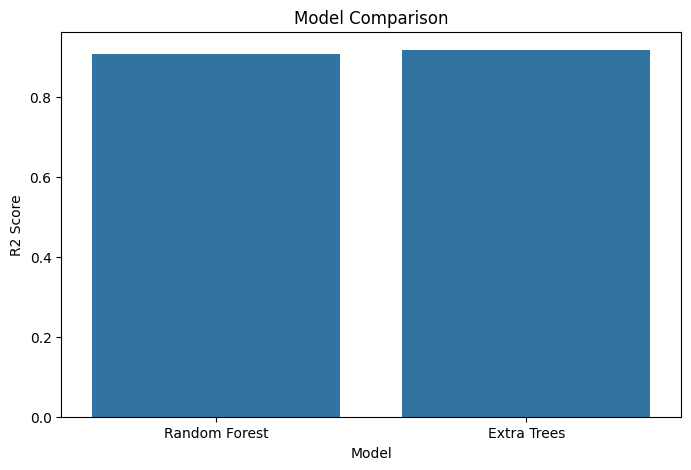

In [54]:
# Model Comparison Plot

plt.figure(figsize=(8,5))

sns.barplot(
    x=results["Model"],
    y=results["R2 Score"]
)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

## Step 18: Conclusion 

### Conclusion

In this Week 4 analysis, engineered features such as the Water-Cement Ratio and log-transformed Age were introduced to improve model learning.

Random Forest and Extra Trees models were trained and evaluated using R² Score and RMSE metrics.

The experiments showed that engineered features improved the predictive performance of the models. Stability testing using different seeds was also performed to analyze the consistency of the results.

Overall, tree-based ensemble models achieved strong performance on the concrete compressive strength dataset.